<a href="https://colab.research.google.com/github/nshanbhag2003/ML-Pipelines/blob/main/AML_Final_Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Preparation

## a) Data loading and processing

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint # for prettier print when it comes to text

In [ ]:
if torch.cuda.is_available():
    print("GPU is available.")
else:
    print("GPU is not available.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GPU is not available.


In [ ]:
import os, tarfile, urllib.request
# The following code downloads the data, extract the tar file into DATA_DIR
# if the folder has not yet been downloaded and extracted
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
DATA_DIR = "aclImdb" # Replace with your download folder

if not os.path.exists(DATA_DIR):
    print("Downloading IMDB dataset...")
    urllib.request.urlretrieve(url, "aclImdb_v1.tar.gz")

    print("Extracting...")
    with tarfile.open("aclImdb_v1.tar.gz", "r:gz") as tar:
        tar.extractall()
    print("Done!")
else:
    print("IMDB dataset already exists.")

Extracting...


/tmp/ipython-input-2607231566.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Done!


In [ ]:
from pathlib import Path
# The following function helps you load the training and test data where each
# review is a single string vector with label 1 if positive, 0 otherwise
# We should be loading 25000 train and 25000 test reviews.

def load_imdb_split(split_dir):
    texts, labels = [], []
    for label_type in ["pos", "neg"]:
        dir_path = Path(split_dir)/label_type
        for file_path in dir_path.iterdir():
            with open(file_path, encoding="utf-8") as f:
                texts.append(f.read())
            labels.append(1 if label_type == "pos" else 0)
    return texts, labels

train_texts, train_labels = load_imdb_split(DATA_DIR + "/train")
test_texts, test_labels   = load_imdb_split(DATA_DIR + "/test")

print(f"Loaded {len(train_texts)} train and {len(test_texts)} test reviews.")

Loaded 25000 train and 25000 test reviews.


In [ ]:
# Display the first train review's first 500 characters
pprint(train_texts[0][:500])

("As I watched one of Orson Welles' last contributions to Hollywood as a "
 'filmmaker, I knew I was watching a great movie unfold, though at times I did '
 'not know why. The story in The Lady from Shanghai has the prime elements of '
 'a film-noir: average-Joe lead, femme fatale, conspicuous supporting '
 'characters, and a comprehensible if somewhat convoluted plot structure. It '
 "is an entertaining ride, and it's filled to the brim with Welles' unique "
 'gifts as a director, but there are scenes that tend to just ')


## b) Using a pretrained `Word2Vec` embedding

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 54.6 MB/s eta 0:00:00


In [ ]:
def load_embedding_model():
    """ Load word2vec Vectors
        Return:
            wv_from_bin: All embeddings
    """
    import gensim.downloader as api
    wv_from_bin = api.load("word2vec-google-news-300")
    print("Loaded vocab size %i" % len(list(wv_from_bin.index_to_key)))
    return wv_from_bin
wv_from_bin = load_embedding_model()

[==================================================] 100.0% 1662.8/1662.8MB downloaded
Loaded vocab size 3000000


In [ ]:
import re, html, unicodedata
from sklearn.feature_extraction.text import CountVectorizer
# Here we give an example of steps one can take when cleaning text data before construction BoW
# basic_clean will be a custom function we can establish for specific cleaning steps. Here IMDB
# reviews are scrapped from the web page, the url and tag replacement steps can be crucial here
# depending on the downstream method

URL_RE   = re.compile(r'https?://\S+|www\.\S+')
TAG_RE   = re.compile(r'<[^>]+>')
NUM_RE   = re.compile(r'\b\d+([.,]\d+)*\b')
WS_RE    = re.compile(r'\s+')
APOSTROPHE_RE = re.compile(r"[’`´]")
CONTRACTIONS = {
    "can't": "can not", "won't": "will not", "n't": " not",
    "'re": " are", "'s": " is", "'d": " would", "'ll": " will", "'ve": " have", "'m": " am"
}

def basic_clean(text):
    text = html.unescape(text) # HTML entities & tags removal
    text = TAG_RE.sub(' ', text)
    def strip_accents(s):
      return ''.join(c for c in unicodedata.normalize('NFKD', s) if not unicodedata.combining(c))
    text = strip_accents(text) #  normalize unicode & accents
    text = APOSTROPHE_RE.sub("'", text) # normalize apostrophes to plain '
    text = URL_RE.sub(' <url> ', text) # replace urls/emails/numbers with placeholders
    text = re.sub(r'\S+@\S+\.\S+', ' <email> ', text)
    text = NUM_RE.sub(' <num> ', text)
    for k, v in CONTRACTIONS.items(): #  expand contractions (eg negations)
        text = text.replace(k, v)
    text = re.sub(r"[^a-z0-9<> ]+", " ", text) #  remove punctuation (keep spaces and angle-bracket tokens)
    text = WS_RE.sub(' ', text).strip() # collapse whitespace
    return text

In [ ]:
# We iterate all the corpus through our cleaning functions and tokenize it
# You can use some of the previously defined functions

def tokenize(s):
    s = s.lower()
    s = re.sub(r"[^a-z0-9']+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s.split()

def clean_tokenize(data_text):
    clean_train = [basic_clean(document) for document in data_text]
    tokens = [tokenize(clean_doc) for clean_doc in clean_train]
    return tokens

train_data = clean_tokenize(train_texts)
test_data = clean_tokenize(test_texts)

In [ ]:
from collections import Counter

def build_vocab(token_docs, max_words=30000, skip_top=0, specials=("<pad>","<oov>")):
    PAD, OOV = specials
    freq = Counter([w for doc in token_docs for w in doc])
    most_common = [w for w,_ in freq.most_common(max_words + skip_top)][skip_top:]
    vocab = [PAD, OOV] + most_common
    word2idx = {w:i for i,w in enumerate(vocab)}
    return vocab, word2idx

vocab, word2idx = build_vocab(train_data)

def build_w2v_embedding_matrix(word2idx, wv, pad_idx=0, oov_idx=1, rand_scale=0.6):
    V = len(word2idx)
    D = wv.vector_size
    emb = np.random.normal(scale=rand_scale, size=(V, D)).astype("float32")
    emb[pad_idx] = 0.0

    found, known_rows = 0, []
    for w, i in word2idx.items():
        if w in wv:
            emb[i] = wv[w]
            found += 1
            if i not in (pad_idx, oov_idx):
                known_rows.append(i)

    if known_rows:
        emb[oov_idx] = emb[known_rows].mean(axis=0)

    print(f"Matched {found}/{V} ({found/V:.1%}) words to pretrained vectors.")
    return torch.tensor(emb)

In [ ]:
all_lens = np.array([len(s) for s in train_data])
for p in (90, 95, 98, 99):
    print(f"P{p}: {np.percentile(all_lens, p):.0f}")

# e.g., pick 95th percentile as MAX_LEN:
MAX_LEN = int(np.percentile(all_lens, 95))
print("Chosen MAX_LEN:", MAX_LEN)

# Estimate truncation rate:
trunc_rate = (all_lens > MAX_LEN).mean()
print(f"Truncation rate at MAX_LEN={MAX_LEN}: {trunc_rate*100:.2f}%")

P90: 456
P95: 599
P98: 788
P99: 910
Chosen MAX_LEN: 599
Truncation rate at MAX_LEN=599: 4.99%


In [ ]:
from torch.utils.data import Dataset, DataLoader


def encode(doc, word2idx, oov_idx=1):
    return [word2idx.get(w, oov_idx) for w in doc]

def pad_to_max_len(ids, max_len=600, pad_idx=0):
    ids = ids[:max_len]
    if len(ids) < max_len:
        ids += [pad_idx] * (max_len - len(ids))
    return ids


class TextDataset(Dataset):
  def __init__(self, data, labels, word2idx):
    assert len(data) == len(labels)
    self.X = []
    self.y = []
    for toks, y in zip(data, labels):
        ids = encode(toks, word2idx)
        ids = pad_to_max_len(ids)
        self.X.append(torch.tensor(ids, dtype=torch.long))
        self.y.append(torch.tensor([y], dtype=torch.float32))

  def __len__(self):
    return len(self.X)

  def __getitem__(self, i):
      return self.X[i], self.y[i]

train_dataloader = DataLoader(TextDataset(train_data, train_labels, word2idx),batch_size=64, shuffle=True)
test_dataloader = DataLoader(TextDataset(test_data, test_labels, word2idx), batch_size=64)

# 1. Bi-directional LSTM


## Question 1.
Create the sentiment classifier class with Bi-LSTM by combining:
 - an **embedding** layer: taking the word embeddings defined previously, with frozen weights so they are not retrained during model training.
 - the **Bi-LSTM layer**: with 150 memory size
 - the **convolutional layer**: with 100 filters with window size of 3.
 - final **classifier head** comprised of a drop-out layer with rate 0.7 and linear layer on the concatenated bi-LSTM output.


In [ ]:
embedding_matrix = build_w2v_embedding_matrix(
    word2idx,
    wv_from_bin,
    pad_idx=0,
    oov_idx=1
)
print(f"Embedding matrix shape: {embedding_matrix.shape}")
print(f"Vocab size: {embedding_matrix.shape[0]}")
print(f"Embedding dimension: {embedding_matrix.shape[1]}")

Matched 22514/30002 (75.0%) words to pretrained vectors.
Embedding matrix shape: torch.Size([30002, 300])
Vocab size: 30002
Embedding dimension: 300


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

#### YOUR CODE ####

class C_BiLSTM(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        pretrained_embeddings,
        hidden_dim=150,
        num_filters=100,
        kernel_size=3,
        dropout=0.7,
        num_classes=2
    ):
        super().__init__()

        # embedding from Google News word2vec ()
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=0
        )
        self.embedding.weight.data.copy_(pretrained_embeddings)
        self.embedding.weight.requires_grad = False

        # convolution layer with 100 filters of window size 3
        self.conv = nn.Conv1d(
            in_channels=embed_dim,
            out_channels=num_filters,
            kernel_size=kernel_size,
            padding=kernel_size // 2
        )

        # bi-directional LSTM with memory size dim of 150 per direction
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        # classifier head
        self.dropout = nn.Dropout(dropout)
        self.clf = nn.Linear(
            2 * hidden_dim + num_filters,
            num_classes
        )

    def forward(self, x):

        # embedding
        emb = self.embedding(x)

        # CNN branch
        conv_in = emb.transpose(1, 2)
        conv_out = F.relu(self.conv(conv_in))
        conv_feat = F.max_pool1d(
            conv_out, conv_out.size(2)
        ).squeeze(2)

        # Bi-LSTM branch
        _, (h_n, _) = self.lstm(emb)
        lstm_feat = torch.cat(
            (h_n[-2], h_n[-1]), dim=1
        )

        # concatenate + classify
        features = torch.cat((lstm_feat, conv_feat), dim=1)
        features = self.dropout(features)
        logits = self.clf(features)

        return logits

## Question 2.

Complete the code to run training. Instantiate the model, define the criterion.

In [ ]:
V = len(vocab)
D = embedding_matrix.shape[1]
hidden_dim = 150
num_filters = 100
kernel_size = 3
dropout = 0.7

#### YOUR CODE HERE ####
model = C_BiLSTM(
    vocab_size=V,
    embed_dim=D,
    pretrained_embeddings=embedding_matrix,
    hidden_dim=hidden_dim,
    num_filters=num_filters,
    kernel_size=kernel_size,
    dropout=dropout,
).to(device)

#### YOUR CODE HERE ####
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # matches the paper

## Question 3.

Complete the training loop and evaluation. Train the model for 10 epochs and plot the learning curves and classification diagnostics. **Add** a few lines of a code so that you can save the best model in the sense of the model with lowest validation loss.

 Hint: You can use functions defined in HW 5.

In [ ]:
#### YOUR CODE HERE ####
from sklearn.metrics import confusion_matrix, classification_report
import torch

def train(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss, total_correct, total_examples = 0, 0, 0

    for X, y in dataloader:
        X = X.to(device)
        y = y.to(device).squeeze(1).long()

        optimizer.zero_grad()
        logits = model(X)

        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total_examples += X.size(0)

    avg_loss = total_loss / total_examples
    avg_acc = total_correct / total_examples
    return avg_loss, avg_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss, total_correct, total_examples = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device).squeeze(1).long()

            logits = model(X)
            loss = criterion(logits, y)

            total_loss += loss.item() * X.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == y).sum().item()
            total_examples += X.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    avg_loss = total_loss / total_examples
    avg_acc = total_correct / total_examples
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, digits=4)

    return avg_loss, avg_acc, cm, report

 10%|█         | 1/10 [01:27<13:05, 87.30s/it]

Epoch 1/10 | Train Loss: 0.6681, Train Acc: 0.5931 | Val Loss: 0.6056, Val Acc: 0.6805


 20%|██        | 2/10 [02:54<11:40, 87.51s/it]

Epoch 2/10 | Train Loss: 0.5635, Train Acc: 0.7090 | Val Loss: 0.4900, Val Acc: 0.7805


 30%|███       | 3/10 [04:22<10:13, 87.60s/it]

...

Epoch 8/10 | Train Loss: 0.3858, Train Acc: 0.8312 | Val Loss: 0.4188, Val Acc: 0.8065


 90%|█████████ | 9/10 [13:09<01:27, 87.83s/it]

Epoch 9/10 | Train Loss: 0.3676, Train Acc: 0.8391 | Val Loss: 0.4331, Val Acc: 0.8002


100%|██████████| 10/10 [14:37<00:00, 87.76s/it]

Epoch 10/10 | Train Loss: 0.3420, Train Acc: 0.8531 | Val Loss: 0.4296, Val Acc: 0.7994


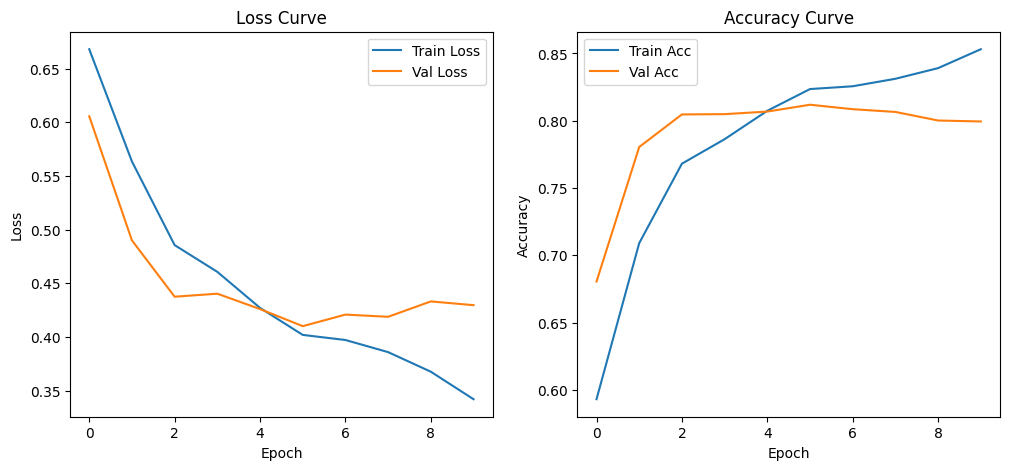

In [ ]:
#### YOUR CODE HERE ###

import matplotlib.pyplot as plt
import tqdm
import torch

EPOCHS = 10
best_val_loss = float("inf")

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

train_loader = train_dataloader
val_loader = test_dataloader

# Train model
for epoch in tqdm.tqdm(range(EPOCHS)):
    train_loss, train_acc = train(
        model, train_loader, criterion, optimizer, device
    )
    val_loss, val_acc, cm, report = evaluate(
        model, val_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # Evaluate
    # Retain best model ie model with lowest validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_bilstm_model.pt")

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

# Plot curves
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.show()

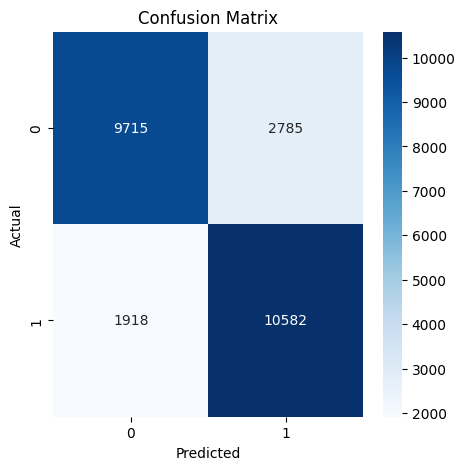

              precision    recall  f1-score   support

           0     0.8351    0.7772    0.8051     12500
           1     0.7917    0.8466    0.8182     12500

    accuracy                         0.8119     25000
   macro avg     0.8134    0.8119    0.8117     25000
weighted avg     0.8134    0.8119    0.8117     25000



In [ ]:
#### YOUR CODE HERE ###

# Show diagnostics
import seaborn as sns

# Load best model
model.load_state_dict(torch.load("best_bilstm_model.pt"))
model.to(device)

# Final evaluation
val_loss, val_acc, cm, report = evaluate(
    model, val_loader, criterion, device
)

# Confusion matrix
plt.figure(figsize=(5,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[0, 1],
    yticklabels=[0, 1]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification report
print(report)

# Implementing the attention mechanism


## Question 4.
The paper uses a simple attention mechanism to focus on the features of keywords.
1)  Can you explain in a few words what the attention mechanism does?
2)  Implement the attention mechanism by completing the code.

**Your answer**: An attention mechanism allows the model to focus on the most informative words in a sentence when making a prediction.  Rather than treating all tokens equally, the model learns a set of weights that indicate how important each word is for the task.  The final sentence representation is computed as a weighted combination of word-level features, so keywords that carry strong sentiment contribute more than irrelevant or common words.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

#### YOUR CODE HERE ####
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.w = nn.Linear(hidden_dim, hidden_dim, bias=True)
        self.v = nn.Parameter(torch.randn(hidden_dim))

    def forward(self, h):
        """
        h: (B, T, H) hidden states (either forward or backward)
        """

        # u_h = tanh(W h + b)
        u = torch.tanh(self.w(h))

        # dot-product attention
        scores = torch.matmul(u, self.v)

        # mask padded positions (where h is all zeros)
        mask = (h.abs().sum(dim=2) == 0)
        scores = scores.masked_fill(mask, -1e9)

        # normalized attention weights
        alpha = F.softmax(scores, dim=1)

        # context vector
        context = torch.sum(alpha.unsqueeze(-1) * h, dim=1)

        return context, alpha

## Question 5.
Now you have implemented the dot-product attention but we need to plug it in the architecture. Complete the code, this should be similar to question 1. Specify criterion, and use your training and validation loops from question 2 and 3 to evaluate the model.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

#### YOUR CODE ####

class AC_BiLSTM(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim=150,
        num_filters=100,
        kernel_size=3,
        pretrained_embeddings=None,
        freeze_embeddings=True,
        dropout=0.7,
        num_classes=2
    ):
        super().__init__()

        # embedding from Google News word2vec ()
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=0
        )
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(pretrained_embeddings)
        self.embedding.weight.requires_grad = not freeze_embeddings

        # convolution layer with 100 filters of window size 3
        self.conv = nn.Conv1d(
            in_channels=embed_dim,
            out_channels=num_filters,
            kernel_size=kernel_size,
            padding=kernel_size // 2
        )

        # bi-directional LSTM with memory size dim of 150 per direction
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        # attention
        self.attention_f = Attention(hidden_dim)
        self.attention_b = Attention(hidden_dim)

        # classifier head
        self.dropout = nn.Dropout(dropout)
        self.clf = nn.Linear(
            2 * hidden_dim + num_filters,
            num_classes
        )

    def forward(self, x):

        emb = self.embedding(x)

        # CNN branch
        conv_in = emb.transpose(1, 2)
        conv_out = F.relu(self.conv(conv_in))
        conv_feat = F.max_pool1d(
            conv_out, conv_out.size(2)
        ).squeeze(2)

        # Bi-LSTM
        lstm_out, _ = self.lstm(emb)
        h_f, h_b = lstm_out[:, :, :150], lstm_out[:, :, 150:]

        # Attention
        C_f, _ = self.attention_f(h_f)
        C_b, _ = self.attention_b(h_b)

        features = torch.cat([C_f, C_b, conv_feat], dim=1)
        features = self.dropout(features)
        logits = self.clf(features)

        return logits

In [ ]:
#### YOUR CODE HERE ####
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

V = len(vocab)
D = embedding_matrix.shape[1]

model = AC_BiLSTM(
    vocab_size=V,
    embed_dim=D,
    hidden_dim=150,
    num_filters=100,
    kernel_size=3,
    pretrained_embeddings=embedding_matrix,
    freeze_embeddings=True,
    dropout=0.7,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
#### YOUR CODE ####
EPOCHS = 10
best_val_loss = float("inf")

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

# Train and evaluate
# Retain best model ie model with lowest validation loss

for epoch in range(EPOCHS):
    train_loss, train_acc = train(
        model, train_dataloader, criterion, optimizer, device
    )
    val_loss, val_acc, cm, report = evaluate(
        model, test_dataloader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_ac_bilstm.pt")

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f} | "
        f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}"
    )

Epoch 1/10 | Train Loss=0.5059, Train Acc=0.7463 | Val Loss=0.4795, Val Acc=0.7838
Epoch 2/10 | Train Loss=0.4286, Train Acc=0.8113 | Val Loss=0.3962, Val Acc=0.8246
Epoch 3/10 | Train Loss=0.3732, Train Acc=0.8388 | Val Loss=0.3763, Val Acc=0.8331
Epoch 4/10 | Train Loss=0.3331, Train Acc=0.8611 | Val Loss=0.3365, Val Acc=0.8550
Epoch 5/10 | Train Loss=0.2936, Train Acc=0.8787 | Val Loss=0.3208, Val Acc=0.8616
Epoch 6/10 | Train Loss=0.2624, Train Acc=0.8922 | Val Loss=0.3112, Val Acc=0.8675
Epoch 7/10 | Train Loss=0.2407, Train Acc=0.9036 | Val Loss=0.3213, Val Acc=0.8689
Epoch 8/10 | Train Loss=0.2191, Train Acc=0.9121 | Val Loss=0.3249, Val Acc=0.8608
Epoch 9/10 | Train Loss=0.1940, Train Acc=0.9240 | Val Loss=0.3155, Val Acc=0.8680
Epoch 10/10 | Train Loss=0.1806, Train Acc=0.9297 | Val Loss=0.3407, Val Acc=0.8696


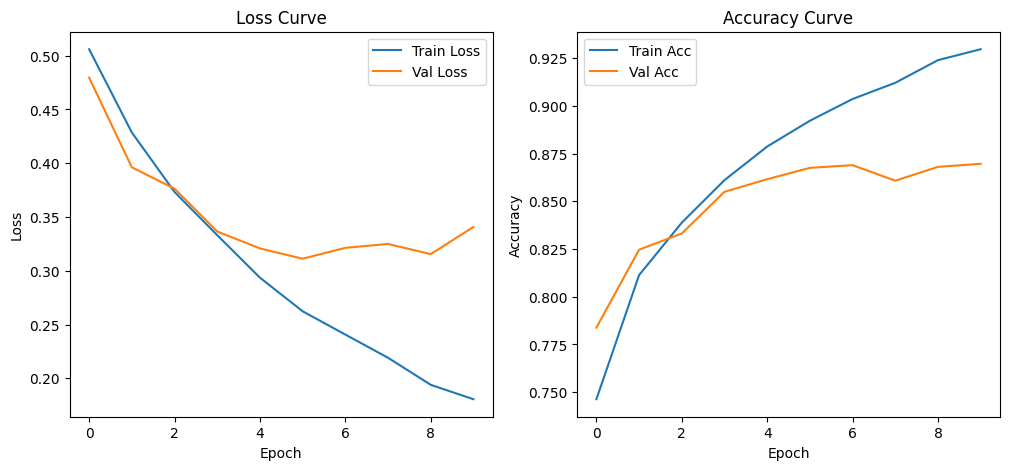

In [ ]:
#### YOUR CODE ####
# Plot learning curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

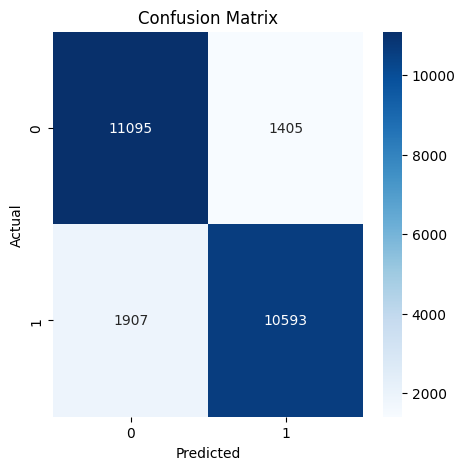

              precision    recall  f1-score   support

           0     0.8533    0.8876    0.8701     12500
           1     0.8829    0.8474    0.8648     12500

    accuracy                         0.8675     25000
   macro avg     0.8681    0.8675    0.8675     25000
weighted avg     0.8681    0.8675    0.8675     25000



In [ ]:
#### YOUR CODE ####
# Show diagnostics
import seaborn as sns

model.load_state_dict(torch.load("best_ac_bilstm.pt"))
model.to(device)

_, _, cm, report = evaluate(
    model, test_dataloader, criterion, device
)

plt.figure(figsize=(5,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[0,1],
    yticklabels=[0,1]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(report)

## Question 6
You can refer to the paper for this question.
1) What is the purpose of the convolutional layer in this architecture?
2) You were told to concatenate the forward and backward hidden states output from Bi-LSTM, why ?
3) Why does adding soft attention improve performance of the model?
4) Compare the performance results to the results you obtained in HW5. Which model would you choose? What about model complexity in each case (with or without fine-tuning?, you can give an estimate of the nearest order of magnitude of the model's number of trainable parameters)?
5) Can you explain in short sentences if you were to swap the convolutional layer and embedding to a pretrained transformer head like BERT to combine it with the bidirectional LSTM, how would you do?

**Your answer**:
1. The convolutional layer is used to capture local n-gram patterns in the text, such as short phrases or combinations of neighboring words that are strongly indicative of sentiment. By applying multiple filters with a fixed window size, the CNN extracts features that complement the sequential information modeled by the Bi-LSTM.  This allows the architecture to detect cues such as “not good” or “very bad” even if they appear at different positions in the sentence, improving robustness and performance.

2. Concatenating the forward and backward hidden states allows the model to incorporate information from both past and future context around each word.
The forward LSTM captures dependencies from left to right, while the backward LSTM captures dependencies from right to left, and each direction may encode complementary information. By combining them, the representation at each position becomes richer and more informative, leading to better classification performance.

3. Soft attention improves model performance by allowing the network to focus on the most informative parts of the input sequence when forming a sentence representation. Instead of compressing all time steps equally, attention assigns higher weights to tokens that are more relevant to the task, such as sentiment-bearing keywords. This reduces noise from irrelevant or padded tokens and results in more interpretable representations.

4. Compared to HW5, the BiLSTM (with or without attention) improves over the Word Embedding + CNN model, reaching about 87% accuracy, and offers more expressive sequence modeling than BOW + Logistic Regression. Although the BOW model achieved slightly higher accuracy in HW5 (88%), its performance relies on task simplicity and ignores word order and context. I would choose the **BiLSTM with attention** because it models long-range dependencies and focuses on informative tokens, leading to more robust and interpretable predictions. For a word-embedding + logistic regression model, the number of trainable parameters is on the order of \(10^3\) when embeddings are frozen (only the classifier is trained), but increases to approximately \(10^7\) if the embeddings are fine-tuned, as the embedding matrix then dominates the model size. BOW + Logistic Regression has on the order of \(10^5\)–\(10^6\) parameters, while the BiLSTM has about \(10^7\) parameters if embeddings are fine-tuned, or closer to \(10^6\) when embeddings are frozen, which helps control overfitting.

5. To combine a pretrained transformer such as BERT with a Bi-LSTM, I would first pass the token IDs through the BERT encoder instead of a static embedding or convolutional layer. The contextualized token embeddings produced by BERT can then be used as the input sequence to the Bi-LSTM.  The Bi-LSTM further refines sequential dependencies on top of BERT’s representations, and the final hidden states  are fed into a classifier.






# 4. *Optional: BERT+Bi-LSTM*

Bonus question: can you rerun the pipeline using a BERT + Bi-LSTM architecture? Note: you should not be using the Word2vec embedding but you can use a pretrained BERT. Justify your choices concisely.

Comment on why BERT is an appropriate transformer-based model for text classification, how does it differ conceptually to LLM architectures?

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Device
torch.set_num_threads(2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
MAX_LEN = 64   # reduced for speed

# Dataset (lazy tokenization)
class BertTextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        return (
            enc["input_ids"].squeeze(0),
            enc["attention_mask"].squeeze(0),
            torch.tensor(self.labels[idx], dtype=torch.float32)
        )

# DataLoaders
train_ds = BertTextDataset(train_texts, train_labels)
test_ds  = BertTextDataset(test_texts,  test_labels)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, num_workers=2)

# Model: BERT + Bi-LSTM
class BERT_BiLSTM(nn.Module):
    def __init__(self, hidden_dim=128, dropout=0.3, freeze_bert=True):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")

        if freeze_bert:
            self.bert.eval()
            for p in self.bert.parameters():
                p.requires_grad = False

        self.lstm = nn.LSTM(
            input_size=self.bert.config.hidden_size,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(2 * hidden_dim, 1)

    def forward(self, input_ids, attention_mask):
        # BERT as frozen feature extractor
        with torch.no_grad():
            bert_out = self.bert(
                input_ids=input_ids,
                attention_mask=attention_mask
            ).last_hidden_state

        _, (h_n, _) = self.lstm(bert_out)
        h = torch.cat([h_n[-2], h_n[-1]], dim=1)
        h = self.dropout(h)
        return self.classifier(h).squeeze(-1)


# Training / Evaluation
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_correct, total = 0, 0, 0

    for input_ids, attn_mask, labels in loader:
        input_ids = input_ids.to(device)
        attn_mask = attn_mask.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attn_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds = (torch.sigmoid(logits) >= 0.5).long()
        total_correct += (preds == labels.long()).sum().item()
        total += labels.size(0)

    return total_loss / total, total_correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for input_ids, attn_mask, labels in loader:
            input_ids = input_ids.to(device)
            attn_mask = attn_mask.to(device)
            labels = labels.to(device)

            logits = model(input_ids, attn_mask)
            loss = criterion(logits, labels)

            total_loss += loss.item() * labels.size(0)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long()

            total_correct += (preds == labels.long()).sum().item()
            total += labels.size(0)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    return (
        total_loss / total,
        total_correct / total,
        confusion_matrix(all_labels, all_preds),
        classification_report(all_labels, all_preds, digits=4),
    )

# Train
model = BERT_BiLSTM().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-4
)

EPOCHS = 3
best_val_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_acc, cm, report = eval_epoch(model, test_loader, criterion)

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        torch.save(model.state_dict(), "best_bert_bilstm.pt")

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
        f"Val Loss {va_loss:.4f} Acc {va_acc:.4f}"
    )

print(report)

Using device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

KeyboardInterrupt: 

I tried running the above code for an hour but it didn't finish...

**BERT + Bi-LSTM pipeline:**  
To rerun the pipeline with BERT, the Word2Vec embedding and convolutional layers are replaced by a pretrained BERT encoder (e.g., `bert-base-uncased`). Text is tokenized using BERT’s tokenizer and passed through BERT to obtain contextualized token embeddings. These embeddings are then fed into a Bi-LSTM to further model sequential dependencies, followed by attention pooling and a classification head.

**Justification of choices:**  
BERT provides rich, context-aware token representations that already encode syntax and semantics, reducing the need for feature extractors like CNNs.

**Why BERT is appropriate for text classification:**  
BERT is pretrained using masked language modeling and next-sentence prediction, enabling it to capture deep bidirectional context at the token level.

**Difference from LLM architectures:**  
BERT is an *encoder-only* transformer designed for understanding tasks, producing fixed representations optimized for classification and inference. In contrast, LLMs are typically *decoder-only* or encoder–decoder architectures trained for text generation, optimized to predict the next token rather than produce representations for downstream classifiers.
